# Assignment 1 - Particle filter

- **Topic:** Designing a particle filter to estimate the position using magnetic field information

- **Assessment:** The assignment will be graded according to the rubric found on Brightspace

- **Deadline:**  27-02-2025, 17:00
- **Submitting: SUBMIT ONLY `assignment3_groupNumber.ipynb` TO BRIGHTSPACE**. 
where groupNumber is your
 group number

## Instructions
**Installation:** 
The virtual environment `venvPSF` has all the necessary packages pre-installed. Make sure to select the virtual environment when running the code. This can be done in the Jupyter notebook (in vscode) by clicking select kernel in the top right, then python environments, then myenv (python 3.11.9).

If you choose to install the virtual environment yourself, the full list of dependencies is in requirements.txt. This can be done using the steps as shown in howToInstallVirtualEnvironments.txt

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `GP.py`, `helper.py` and `linAlg.py` and the dictionary `modelParameters` as this might result in breaking the assignment.


## AI Related Policy
The use of AI is not allowed.


## Information
Please fill in your group number, names and student numbers in the cell below.



In [1]:
''' YOUR ANSWER HERE '''
groupNumber = 22

STUDENT_1_NAME = "Santiago Terreno Duarte"
STUDENT_1_STUDENT_NUMBER = "6144683"

STUDENT_2_NAME = "Pragun Srivastava"
STUDENT_2_STUDENT_NUMBER = "5542707"

# raise NotImplementedError()

## Objectives

#### Goal

The goal of this assignment is to estimate the position $ \mathbf{p}_t $ of an agent, for $t = {1, ..., \text{T}}$ The agent moves in an indoor environment and gets information about its approximate change in position $ \Delta \mathbf{p}_t $ at every time-step. To model this, you may assume a linear dynamic model of the form:
$$\mathbf{p}_{t + 1} = \mathbf{p}_t + \Delta \mathbf{p}_{t+1} + \mathbf{w}_{t+1}$$

Where:

- $\mathbf{p}_t$ is a 3-dimensional position vector of the agent at time $t$. 

- $\Delta \mathbf{p}_t$ is the change in positon.

- $\mathbf{w}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{Q})$ is Gaussian white noise.

- $ \mathbf{Q} \in \mathbb{R}^{3 \times 3} $ is the covariance of the process noise.

Since the information of the change in position $ \Delta \mathbf{p}_t$ contains errors, the position estimates from the dynamic model will drift. This means that over time, the agent will lose track of where it actually is. To remedy this, the agent is carrying a magnetometer, and has a map of the magnetic field. The magnetometer samples a measurement of the magnetic field $\mathbf{y}_t$ at every position $\mathbf{p}_t$. The map of the magnetic field is modeled by a non-linear function: a reduced rank Gaussian process (you do not need to understand, model or change the GP model, only to call the function evaluation). This results in the non-linear measurement model:
$$ \mathbf{y}_t = f(\mathbf{p}_t) + \mathbf{v}_t $$

Where:

- $\mathbf{y}_t$ is a 3-dimensional measurement vector of the magnetic field at time-step $t$.

- $f(\cdot)$ is the reduced rank Gaussian process function.

- $\mathbf{v}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{R})$ is Gaussian white noise.

- $ \mathbf{R} \in \mathbb{R}^{3 \times 3} $ is the covariance of the measurement noise.


#### First load in the data
To start, first load in the data below
All variables you will use are numpy arrays, where
- `magnetometerMeasurements` $\in \mathbb{R}^{3 \times \text{T}}$ is a numpy array containing the magnetometer measurements
- `magnetometerInitialPosition` $\in \mathbb{R}^{3 \times 1}$ is a numpy array containing the initial position of the magnetometer
- `deltaMagnetometerPositions` $\in \mathbb{R}^{3 \times \text{T}}$ is a numpy array containing the change in position of the magnetometer

#### Warning
- Additionally you are provided with a dictionary modelParameters which is used in creating magnetic field maps. DO NOT CHANGE dictionary as this might break the assignment. To create the particle filter you DO NOT need this dictionary.

In [2]:
''' DO NOT CHANGE THE CODE BELOW '''
import numpy as np
import matplotlib.pyplot as plt

import GP as GP
import linAlg as linAlg
import helper as helper
np.random.seed(groupNumber)

''' load in the data'''
(magnetometerMeasurements, 
 magnetometerInitialPosition, 
 deltaMagnetometerPositions,
 modelParameters) = helper.initializeParticleFilterAssignment(groupNumber % 29)


Below, a function is given to plot the map of the magnetic field and the ground truth position of the path taken by the agent. The agent does not know this path, it only has access to its initial position, the change in position at every time-step and the magnetometer measurements. 

Your first task it to use the agent's dynamic model to try and reconstruct the ground truth path. This is also known as dead reckoning and should be done using data stored in the variables `magnetometerInitialPosition` and `deltaMagnetometerPositions`. Save the agent's positions according to the dynamic model in the variable `deadReckoning` $\in \mathbb{R}^{3 \times \text{T}}$. Additionally, compare the magnetometer measurements with the map of the magnetic field. To achieve this, store the norm of the magnetic field at every time-step in the variable `magneticFieldNorm` $\in \mathbb{R}^{\text{T}}$.

This function should output three subfigures. Every subfigure includes the magnetic field map in the background. On the left the ground truth positions are plotted together with the dead reckoning positions. In the middle the magnetic field measurements are plotted with  the ground truth positions on top of the magnetic field map. On the right, the magnetic field measurements are plotted with  the ground truth positions over the magnetic field map.

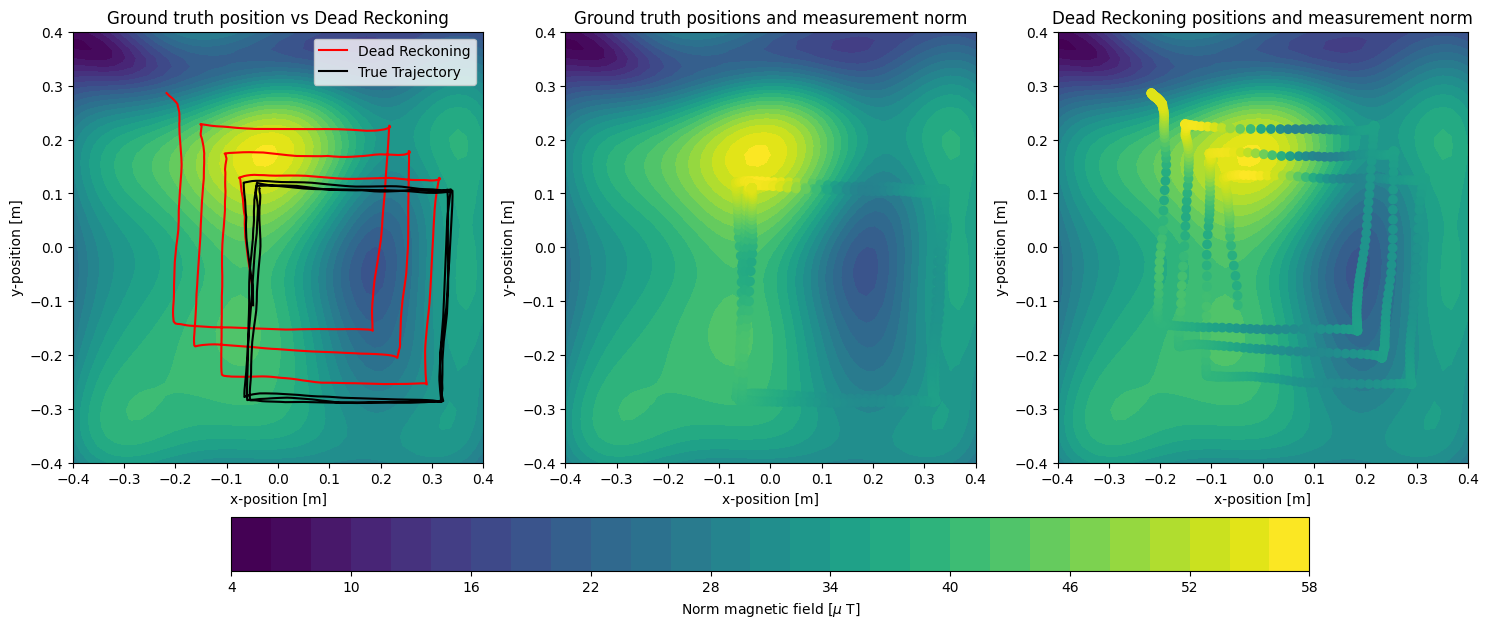

In [3]:
T = deltaMagnetometerPositions.shape[1]
cum_deltas = np.zeros([3,T])
cum_delta = np.zeros(3)
for i in range(T):
    cum_delta += deltaMagnetometerPositions[:,i]
    cum_deltas[:,i] = cum_delta

deadReckoning = magnetometerInitialPosition + cum_deltas
magneticFieldNorm = np.linalg.norm(magnetometerMeasurements, axis = 0)



helper.makeInitialPositionPlots(deadReckoning, magneticFieldNorm, modelParameters)


### Discuss

Comment below on the three plots. 
- 	Does the dynamic model provide accurate enough information about the agent’s position? What will happen to the position of the agent if it moves for longer periods of time?
- Based on the magnetic field map shown in the background, explain why or why not the magnetic field is a good source of information for position estimation. 
- Explain why the measurements do or do not agree with the magnetic field map (for the middle and the right plots).

## Answers

- No, it does not provide accurate enough information. Since the dynamic model contains an error at each step, as time goes on the deviation will keep on increasing. The larger the value of k is, the larger the uncertainty will be of the position at that step (due to the fact that the noise terms are independent, thus variances add up over time), and the more it will deviate from the actual trayectory.

- It is a good source of information, because it changes noticeably across the space. Therefore, knowledge about the magnetic field at the location is helpful to determine the true position. The ideal case would be to have a sufficiently distinct value for the magnetic field for each possible location, in which case (assuming low measurment error) we would in theory not even need the dynamics. A useless case would be to have the same value of the magnetic field across the possible locations. The situation in this exercise is somewhere in the middle, since some values are repeated, so we can use the information to reduce uncertainty rather than determine position exactly, but we also need to rely on the dynamics. Obviously, it is also important for the variation to be noticeable enough, since if it varies but very slightly we are still in the uncertainty region due to measurment error, and the infromation becomes less useful.

- In the middle plot, the measured magnetic field aligns very well with the true magnetic field. The position is the real one here, so any variation between the measured and actual magnetic field is due to measurment errors. However, in the right plot clearly the measured magnetic field is distinct from the one present at the estimated position due to position error, and in this case the larger the index k is the more it differs (but this does not need to happen). This is because we are measuring the magnetic field at the true location but plotting the value in the estimated location, which differs from the real one because errors accumulate over time in the dynamic model (as stated in question 1). As mentioned in the previous question, this means that we can use the magnetic field measurments to correct the estimate of the position. Of course, it is not always the case for the dfference in the magnetic field at the actual and estimated positions to always increase as time passes. If the magnetic field has periodicity over the space, then it could happen that after a certain time the values at the estimated posiiton are similar to those at the actual posiiton. How likely this is depends on the map of the field.

 


### Particle Filter Implementation

One way to reduce the positional drift observed in the figure above, is to use magnetometer measurements. To this end, you will design a particle filter. Your task is to fill in the following three functions.

#### Task
Fill in the `dynamicUpdate()` function according to the dynamic model given above. 

#### Note:
You do not have to change the inputs and outputs to the given functions.


In [4]:

def dynamicUpdate(particlePositions, 
                  deltaPosition,
                  processCovariance,
                  Nparticles):
    
    ''' Dynamic update '''
    mean = np.zeros(3)
    w = np.random.multivariate_normal(mean, processCovariance, size=Nparticles).T

    particlePositions += deltaPosition.reshape([3,1]) + w

    return particlePositions


#### Discuss

Comment on the role of the function of the dynamicUpdate in the particle filter

## Answer

The dynamic update will move the position of the particles according to the dynamic model. This corresponds to the propagation step, samplng N particles at step $k$ from $p(x_{k}|x_{k-1})$. To do this, we just need to sample values from the noise and update the positions by adding the noise to the measured delta. This noise represents the uncertainty in the process, and leads the particles to explore different states. This new values will then be used to update the weights, together with the measurments.

#### Task

Fill in the `measurementUpdate()` according to the measurement model given above. 

To implement the measurement model, you will need to make predictions of the magnetic field. You DO NOT need to create this function yourself. To make predictions, use the function `GP.makeMagneticFieldPrediction(positions, modelParameters)` function make sure the input `positions` $\in \mathbb{R}^{3 \times \text{T}} $. The output should be a matrix $\in \mathbb{R}^{3 \times \text{T}}$ magnetic field predictions for every input location.

In [5]:
def measurementUpdate(particlePositions, 
                      particleWeights,
                      magnetometerMeasurement,
                      measurementCovariance,
                      Nparticles,
                      modelParameters):
    
    ''' Measurement update '''
    predictionsMagneticFieldParticles = GP.makeMagneticFieldPrediction(particlePositions, modelParameters)

    invR = np.linalg.inv(measurementCovariance)
    detR = np.linalg.det(measurementCovariance)

    log_w_norm = np.zeros(Nparticles)

    eps = 1e-300
    
    for i in range(Nparticles):

        dif = magnetometerMeasurement - predictionsMagneticFieldParticles[:,i]
        exp_term = float(-0.5*dif.T@invR@dif)
    
        m = magnetometerMeasurement.size
        log_norm_term = -0.5*(m*np.log(2*np.pi) + np.log(detR))
    
        log_pdf_value = log_norm_term + exp_term
        
        # pdf_value = multivariate_normal.pdf(magnetometerMeasurement, 
        #                                     mean=predictionsMagneticFieldParticles, 
        #                                     cov=measurementCovariance)
    
        log_w_norm[i] = log_pdf_value + np.log(particleWeights[i] + eps)

    log_w_norm_shifted = log_w_norm - np.max(log_w_norm)

    w_norm = np.exp(log_w_norm_shifted)
    
    particleWeights = w_norm/np.sum(w_norm)

    return particlePositions, particleWeights


#### Discuss
Comment on the role of the function of the measurementUpdate in the particle filter

## Answer

The mesurment update serves to update the weights of each particle by multiplying the previous ones with the pdf $p(y_{k}|x_{k})$. This pdf indicates how likely it is to observe a measurment given a certain position, and is computed for the estimated position of each particle. If the value is high, it means that for a given particle it is likely to obtain the measurment given the position of that particle, so that particle gets a high weight. This makes sense because it means that the particles with high weights will be those whose position have a magnetic field that is close to the measured magnetic field, so it is a good estimate for the actual position of the objact. By contrast, a low value of the pdf indicates that the measured value is not close to the value that is expected at the position of the particle, so that position is not likely to be the correct one, and therefore it gets a lower weight. This step only changes the weights, not the particle positions. To do that in accorance with the weights we do resampling.

#### Task

Fill in the remainder of the `particleFilter()` function. 


In [6]:
def particleFilter(particlePositions, 
                   deltaPosition, 
                   magnetometerMeasurement, 
                   processCovariance, 
                   measurementCovariance, 
                   Nparticles,
                   modelParameters):
    ''' Estimates position based on a known map'''

    particleWeights = np.ones(Nparticles)/Nparticles

    if modelParameters['NtimeStepPF'] > 0:
        ''' Dynamic update '''
        particlePositions = dynamicUpdate(particlePositions, 
                                          deltaPosition, 
                                          processCovariance, 
                                          Nparticles)  


    ''' Measurement update '''
    (particlePositions, 
        particleWeights) = measurementUpdate(particlePositions, 
                                             particleWeights,
                                             magnetometerMeasurement, 
                                             measurementCovariance, 
                                             Nparticles,
                                             modelParameters)


    meanPosition = particlePositions @ particleWeights

    max_index = int(np.argmax(particleWeights))
    maxPosition = particlePositions[:, max_index]

    ''' Resampling '''    
    if np.sum(particleWeights) > 1e-12:
        particleWeights /= np.sum(particleWeights)
        indices = helper.systematicResample(particleWeights)
        particlePositions = particlePositions[:, indices]
    else:
        print('Degenerate particles: All the weights are close to zero !!!')
        particleWeights /= np.sum(particleWeights)
        indices = helper.systematicResample(particleWeights)


    return particlePositions, meanPosition, maxPosition


#### Discuss

Comment on the role of the function of the systematicResample in the particle filter

## Answer

Once we update the weights with the measurment update, we get some particles that have high weight and some particles that have low weight. Therefore, it is of interest to be likely to discard the positions of those who have lower weights and reinforce the positions of those with high weights. To do that, we sample N times from the positions of the particles according to the weights (so a particle with high weight may be sampled more than once, and a particle with low weight may be not sampled at all). This ensures that we keep only the positions in which the magnetic field is aligned with the measured value, as explained in last question. We thus eliminate those particles that do not contribute anything to the estimate. After that we reset the weights to be all the same, and continue with the iterations.

#### Task 4

Choose a suitable amount of particles, an initial position covariance, a suitable motion covariance and a suitable measurement covariance.

You could start with the following parameters
- `initalPositionCovariance` = np.eye(3)*0
- `Nparticles` = 100
- `processCovariance` = np.eye(3)*0.001**2
- `measurementCovariance` = np.eye(3)*1.5**2

To get better results, you might have to tune these. 

In [7]:
''' Number of particles used in the particle filter '''
Nparticles = 100


''' Inital position covariance of the position '''
initalPositionCovariance = np.eye(3)*0


''' process covariance and measurement covariance '''
processCovariance = np.eye(3)*0.001**2
measurementCovariance = np.eye(3)*1.5**2


''' Initialize particle positions '''
mu1 = magnetometerInitialPosition.reshape(3,)
particlePositions = np.random.multivariate_normal(
    mean=mu1,
    cov=initalPositionCovariance,
    size=Nparticles
).T


''' Create matrices to store mean and best particle position at every time-step'''
meanParticlePosition = np.zeros([3,modelParameters['NtimeSteps']])
bestParticlePosition = np.zeros([3,modelParameters['NtimeSteps']])

meanParticlePosition[:, 0] = magnetometerInitialPosition.reshape(3,)
bestParticlePosition[:, 0] = magnetometerInitialPosition.reshape(3,)

''' Initialize and run  the Particle Filter '''
modelParameters['NtimeStepPF'] = 0
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosPF = deltaMagnetometerPositions[:,timendx]
    ymeasPF = magnetometerMeasurements[:,timendx]
    (particlePositions, 
     meanParticlePosition[:, timendx+1], 
     bestParticlePosition[:, timendx+1]) = particleFilter(particlePositions, 
                                                          deltaPosPF, 
                                                          ymeasPF, 
                                                          processCovariance, 
                                                          measurementCovariance, 
                                                          Nparticles,
                                                          modelParameters)

    modelParameters['NtimeStepPF'] += 1


### Visualize the output

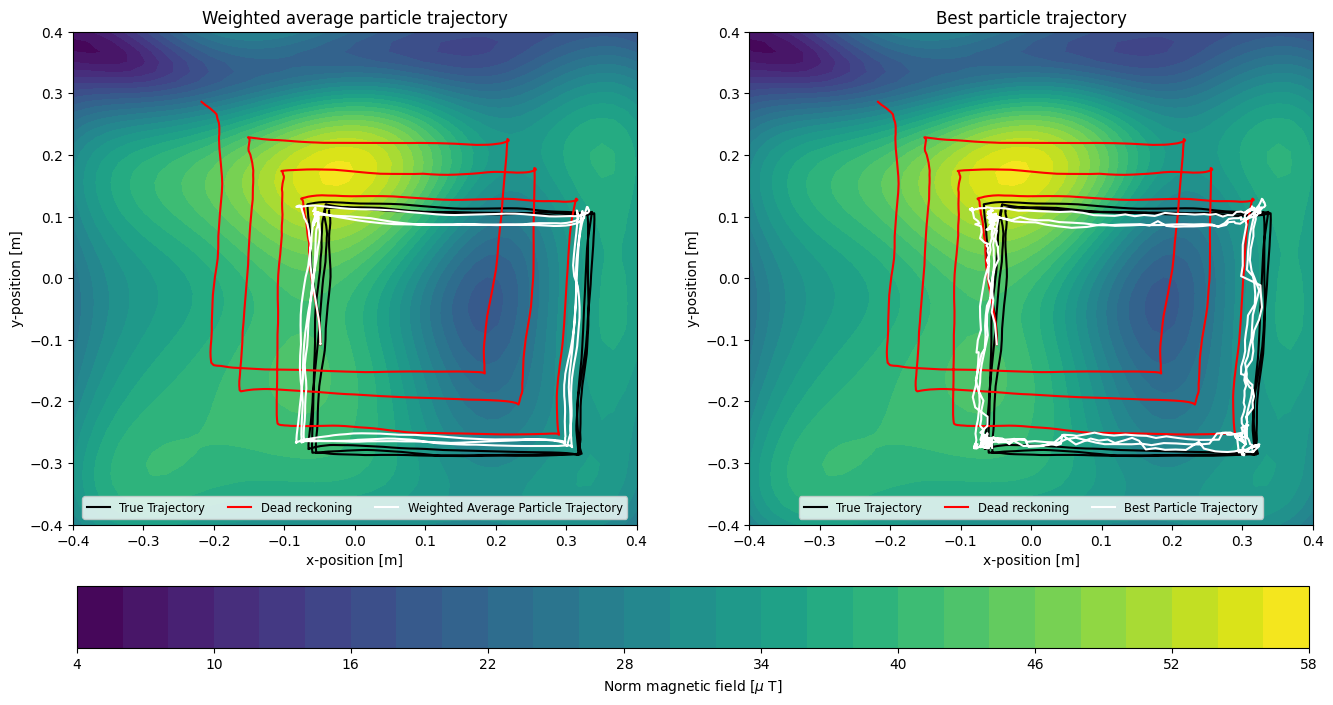

In [8]:
helper.makeParticleFilterPlots(deadReckoning, meanParticlePosition, bestParticlePosition, modelParameters)

#### Discuss

Elaborate on the two plots.
- Does the particle filter improve the position estimates?
- Are the weighted average particle trajectory and the best particle trajectory the same or different? Why is that the case?


## Answers

- Clearly there is a great improvement in the position estimates. These don't drift away as the time index increases, but rather stay more or less within the same sqaure, as the ground truth does. The particle filter continuously corrects the estimate using magnetic field measurements, and the improvement in the estimation confirms our previous observation about the fact that the magnetic field is sufficiently varied accross the moving space. However, there is room for improvement, since we still observe that the estimated trjectory is slightly to the left and up from the ground truth. Increasing the number of particles may reduce this effect.
- They are different because the best particle trajectory is less smooth. That makes sense because the particle that has the highest weight normally changes along the trajectory, and when that occurs there is a jump in the shown path. The weighted average trajectory doesn't coincide with that of any particular particle, but average the position of all of them, and therefore the shown path is smoother.

#### Task

Play around with different parameters. Comment on what happens if we choose lower or higher values for
- `initalPositionCovariance`?
- `Nparticles`?
- `processCovariance`?
- `measurementCovariance`?

And reason about why this is the case

## Answer

- initalPositionCovariance: This reflects the uncertainty in the initial position. If we set it to be a zero matrix, it means that we are absolutely sure about the initial position, and the initial particles will all start at the same point. Conversely if we set it very high it may mean that we have no clue about the initial value and that probably we are initializing with a random or arbitrary position, and the particles will be very spread out. With this dataset, a very small covariance yields the best result, since we do have a measurement for the initial position, and in the plot it can be seen that it is very close to the ground truth. We tried a scaled identity matrix for different multiplier vales, and the higher the value is, the worse the estimated trajectory becomes for the same number of particles. If we increase the initalPositionCovariance, but also increase the number of particles, we eventually reach similar results as before.

- Nparticles: Going back to a zero matrix for initalPositionCovariance, increasing the number of particles tenfold has very little effect in the weighted average particle trajectory, indicating that the initial value of 100 was enough. We expected that with such a large number the effect of having the estimated trajectory being slightly to the left up of the ground truth would be mitigated, but it actually changes very little, so it in no way justifies the considerable larger processing time. There is nevertheless a marked difference in the best particle trajectory, since the path seems less smooth. That is because if there is a larger number of particles then it is more likely that the best particle changes. Conversely, reducing the number of particles decreaes performance, and it is noticeable how the estimated trajectory starts to drift away more and more from the ground truth as we reduce the number of particles. In the extreme case of having just one, the estimated trajectory is very close to the deadReckoning, since that implies not weighting different location possibilities and just moving according to they dynamic model. We keep then the value of 100 for the number of particles, since it balances acceptable computation time with good results.

- processCovariance:  The process covariance indicates how much we trust the dynamic model. Setting it to be the zero matrix will yield exactly the same result as the deadReckoning, since it means that we are absolutely certain about the dynamics, and all the particles just follow the path given by the deltas. If we increse it then the trayectory becomes less smooth and with more jumps, since it trusts the measurments more, and the model is more lkely to keep particles in locations that are far from what the dynamics would predict but whose magnetic field is close to the measured value. In the extreme case of very high processCovariance, the dynamics are ignored and it just jumps to far-away points that happen to have the same magnetic field as the one measured at each step, which is not by any means unique, as discussed previously.

- measurementCovariance: The measurment covariance indicates how much we trust the measurments. A high value is equivalent to trusting the dynamics more, so it produces the same result as having low processCovariance. Surprisingly, a very low value doesn't worsen the result that much (except on the rigth side of the square, which skewes to the left, for a reason that will be mentioned shortly), if we keep the same processCovariance. This is because even though we are telling the model to give very high importance to the measurments, the dynamics keep on playing a role, so the mdoel will always prefer, among different points with the same magnetic field as the measurument, the one that also is in accordance with the dynamics. Also, it makes the trajectory of the best particle to be more similar to the weighted average trajectory, because few particles dominate. The right side of the square gets a markedly worse estimation because, as can be seen in the first deadReckoning plots, the measured magnetic field is higher than the one that it is supposed to have at that location, so giving a lot of weight to the measurments will pull the trajectory to the zone woith a higher magnetic field.

In [9]:
''' Number of particles used in the particle filter '''
Nparticles = 100


''' Inital position covariance of the position '''
initalPositionCovariance = np.eye(3)*0


''' process covariance and measurement covariance '''
processCovariance = np.eye(3)*0.001**2
measurementCovariance = np.eye(3)*1.5**2


''' Initialize particle positions '''
mu1 = magnetometerInitialPosition.reshape(3,)
particlePositions = np.random.multivariate_normal(
    mean=mu1,
    cov=initalPositionCovariance,
    size=Nparticles
).T



''' Create matrices to store mean and best particle position at every time-step'''
meanParticlePosition = np.zeros([3,modelParameters['NtimeSteps']])
bestParticlePosition = np.zeros([3,modelParameters['NtimeSteps']])

meanParticlePosition[:, 0] = magnetometerInitialPosition.reshape(3,)
bestParticlePosition[:, 0] = magnetometerInitialPosition.reshape(3,)

''' Initialize and run the Particle Filter '''
modelParameters['NtimeStepPF'] = 0
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosPF = deltaMagnetometerPositions[:,timendx]
    ymeasPF = magnetometerMeasurements[:,timendx]
    (particlePositions, 
     meanParticlePosition[:, timendx+1], 
     bestParticlePosition[:, timendx+1]) = particleFilter(particlePositions, 
                                                          deltaPosPF, 
                                                          ymeasPF, 
                                                          processCovariance, 
                                                          measurementCovariance, 
                                                          Nparticles,
                                                          modelParameters)

    modelParameters['NtimeStepPF'] += 1


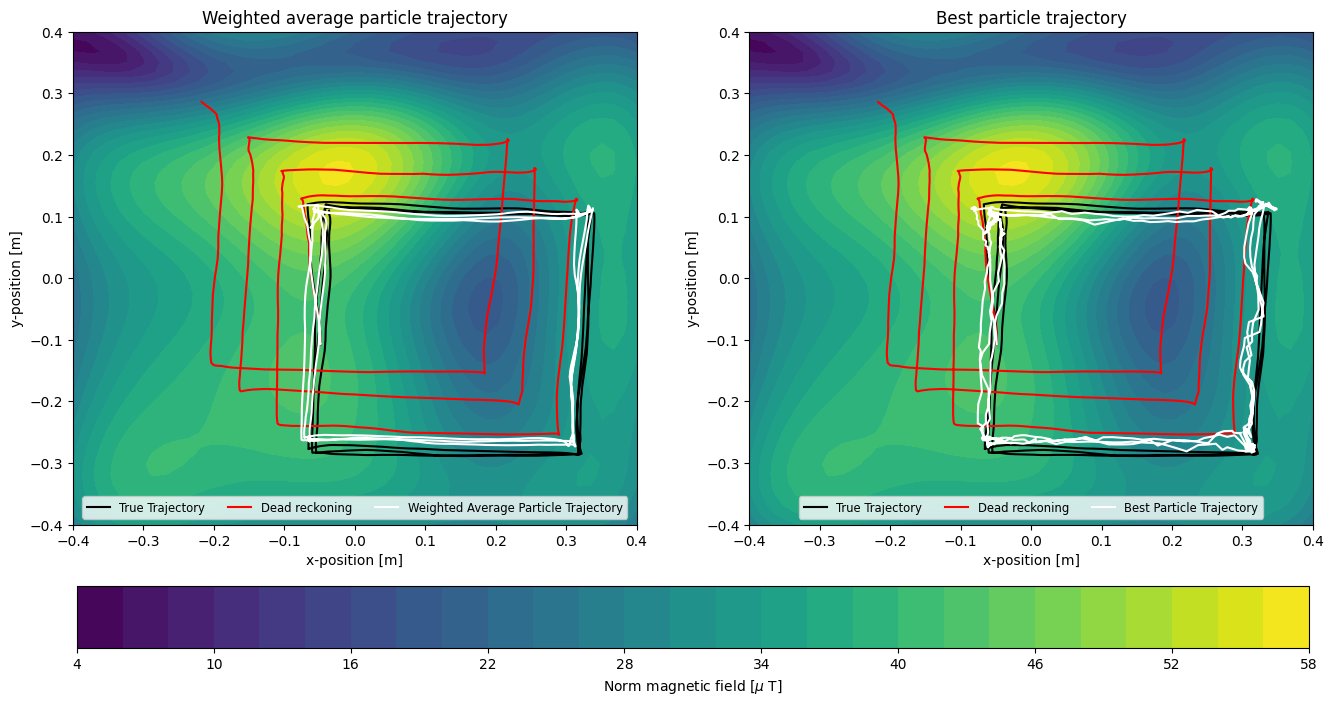

In [10]:
helper.makeParticleFilterPlots(deadReckoning, meanParticlePosition, bestParticlePosition, modelParameters)

#### Discuss

Comment on the reason for choosing a particle filter for this estimation problem.

## Answer

Particle filtering lets us estimate the position of the object given the measurments and the dynamics in a context where the pdf of the state given the measurments is non gaussian. We want to combine the information we have about the dynamics and the measurments, and to do it in a non linear, non-Gaussian posterior we use particle filtering to approximate the posterior with weighted samples. This is the case in this exercise because the magnetic field is given by a nonlinear GP map, so the Kalman filters won't work well. Moreover, in the possible locations the magnetic field is repeated, and therefore the distribution of the posterior is multimodal. In Kalman filtering we also combine information about dynamics and measurment, but with a linear gaussian model we don't need to take samples because we can analytically obtain expressions for the estimates at each time step, so particle filteringis unnecessary in that case becasue it would be less efficient than Kalman filtering.